source of data: [Décès, mortalité, espérance de vie ](https://www.insee.fr/fr/statistiques/8721189) > "DEC3 - Quotients de mortalité – Séries depuis 1994 pour la France et 1946 pour la France métropolitaine"<br>
[List of French departments by life expectancy](https://en.wikipedia.org/wiki/List_of_French_departments_by_life_expectancy) / 
[Продолжительность жизни в департаментах Франции](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_департаментах_Франции) / [Espérance de vie humaine en France](https://fr.wikipedia.org/wiki/Espérance_de_vie_humaine_en_France)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

In [3]:
pd.options.display.min_rows = 8

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'fr', 'nolang']
SELECTED_YEAR = 2025
WHAT_TO_EXPLORE = 'average_last_3' # What type of data to explore:
                            # 'single' - for a single year
                            # 'average_last_3' - average values over all years in load data
NAME_FOR_AVERAGE = '2023–2025'  # designation of the range of years used in titles of charts
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

In [5]:
def load_data(sheet, what_to_explore, year_for_single=SELECTED_YEAR):
    df = pd.read_excel(f'data/3_Quotients_mortalite.xlsx', sheet_name=sheet, skiprows=3, skipfooter=5, index_col=0,
                       decimal=",")

    df.rename(index = lambda year: int(year[:-len(' (p)')]) if (type(year) is str) and year.endswith(' (p)') else \
                                   year,
              columns = lambda age: int(age[:-len(' an')]) if age.endswith(' an') else \
                                    int(age[:-len(' ans')]) if age.endswith(' ans') else \
                                    age,
              inplace = True)

    if (WHAT_TO_EXPLORE == 'single'):
        return df.loc[year_for_single]
    elif (WHAT_TO_EXPLORE == 'average_last_3'):
        return df.iloc[-3:].mean()
    else:
         raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")


series_male = load_data(sheet='FM-Hommes', what_to_explore=WHAT_TO_EXPLORE, year_for_single=SELECTED_YEAR)
series_female = load_data(sheet='FM-Femmes', what_to_explore=WHAT_TO_EXPLORE, year_for_single=SELECTED_YEAR)

df = pd.DataFrame({'male': series_male, 'female': series_female}) / 1000  # values are transformed to percents

df['mΔf'] = df['male'] - df['female']
df['ratio_mf'] = (df['male'] / df['female']).round(2)
df

,male,female,mΔf,ratio_mf
0,0.381667,0.320000,0.061667,1.19
1,0.056333,0.052667,0.003667,1.07
2,0.023000,0.017667,0.005333,1.30
3,0.016333,0.012000,0.004333,1.36
...,...,...,...,...
97,28.149333,22.811333,5.338000,1.23
98,31.054000,25.670000,5.384000,1.21
99,32.810333,28.025667,4.784667,1.17
100,36.315667,30.024000,6.291667,1.21


<br>

<h4>Explore the "plateau"  (21–30 years)</h4>
The code below calculates average values of the probability of dying for the "plateau", and how much people would l

In [7]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = df.loc[plateau_years, ['male', 'female']].mean().to_frame().T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['France']
dfe.round(3)

,male,female,ratio_mf
France,0.063,0.023,2.76


In [8]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,female,ratio_mf,le_ageless_male,le_ageless_female
France,0.063,0.023,2.76,1586,4373


<br>

<h4>Explore the zone of the Gompertz law of mortality  (40–90 years)</h4>
The code below calculates the average annual increase the probability of dying (in percent) and the period during that this indicator doubles (in years), <b>based on the values at the endpoints</b>.<br><i>
(Calculations based on approximation are below, under a chart.)</i>

In [10]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

In [11]:
age_gompertz_start = 40
age_gompertz_stop  = 90
print("increase_rate(%)  doubling   | increase_rate(%)  doubling")
print("            male             |             female")
male_rate_perc, male_period_double = \
    calculate_increase_rate_and_doubling_period(
        age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'male'], df.loc[age_gompertz_stop, 'male'])
female_rate_perc, female_period_double = \
    calculate_increase_rate_and_doubling_period(
        age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'female'], df.loc[age_gompertz_stop, 'female'])
print(f"      {male_rate_perc:5.2f} %  {male_period_double:5.2f} years   |" +
      f"       {female_rate_perc:5.2f} %  {female_period_double:5.2f} years")


increase_rate(%)  doubling   | increase_rate(%)  doubling
            male             |             female
       9.51 %   7.63 years   |       10.51 %   6.93 years


<br>

In [13]:
def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [0, 1] + list(range(5, 96, 5)) + [99, 100]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')
    
    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits
        st = st.replace('padding-right:3ex;', 'padding-right:2.5ex;')

    st = table_header + st + '\n|}'
    return st


if WRITE_TABLE:
    file_name_table = \
        "Table code for probability of dying -single_year" if (WHAT_TO_EXPLORE == 'single')  else \
        "Table code for probability of dying -average"     if (WHAT_TO_EXPLORE == 'average_last_3') else \
        null
    
    table_code = create_table(df, file_header='Probability_of_dying -en.txt', lang='en')
    with open(f"output/{file_name_table} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    table_code = create_table(df, file_header='Probability_of_dying -ru.txt', lang='ru')
    with open(f"output/{file_name_table} -ru.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

In [15]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'fr_name', 'nolang_name', 'color', 'style', 'width', 'alpha'])

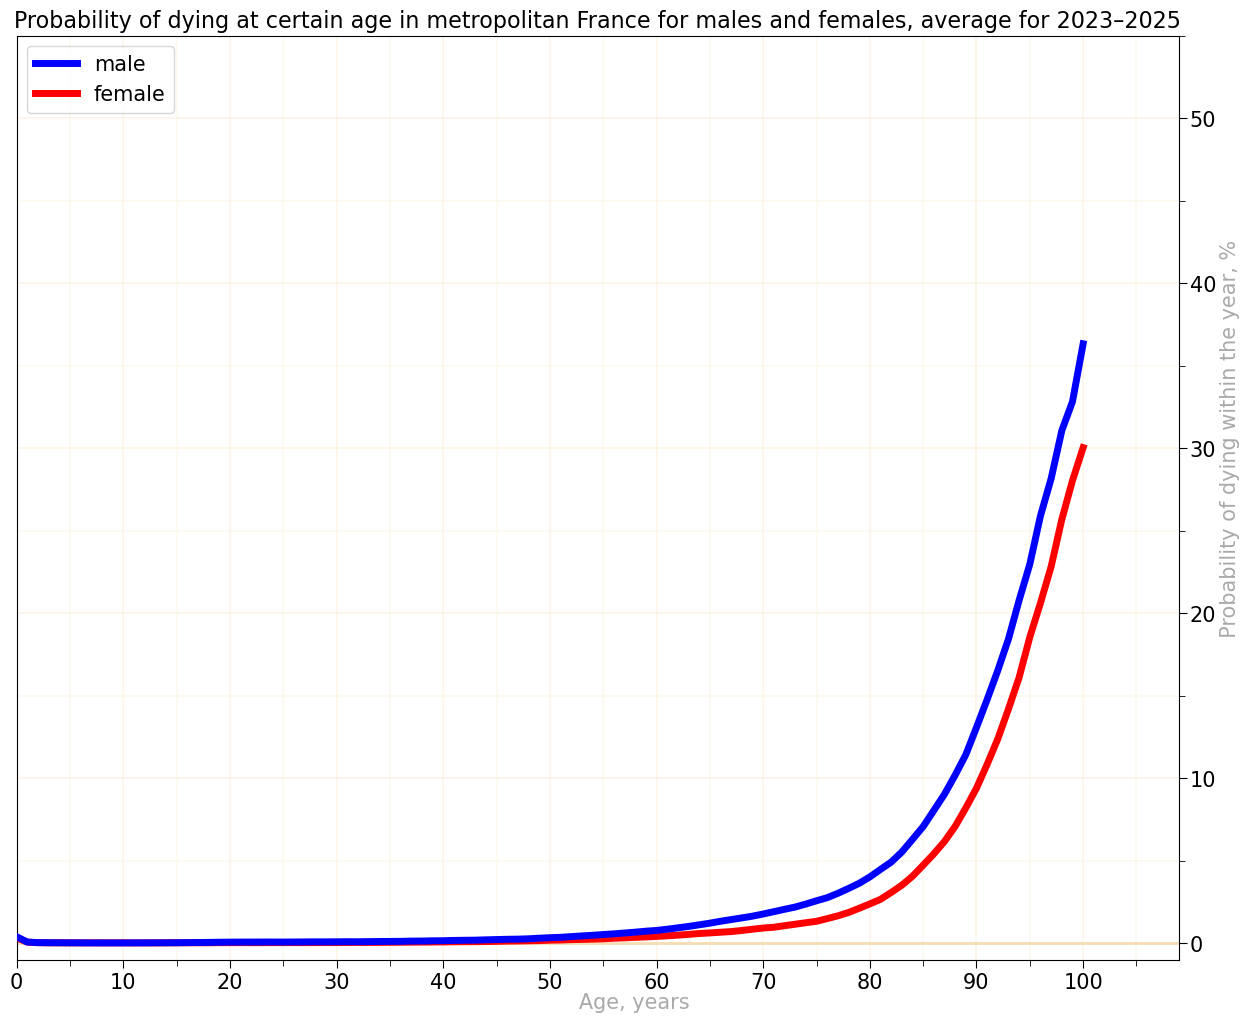

In [16]:
def create_chart(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика", title_fr="Titre du graphique",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)   # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 55
    plt.xlim(0, 109)
    plt.ylim(-1, 55)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_fr if lang=='fr' else " " if lang=='nolang' else title_en,
              fontsize=15 if lang=='ru' else 16.25 if lang=='fr' else 16)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               "               Âge, années" if lang=='fr' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("          Вероятность смерти в течение года, %" if lang=='ru' else
               "       Probabilité de décès dans un an, %" if lang=='fr' else
               " " if lang=='nolang' else
               "                  Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].fr_name if lang=='fr' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -fr' if lang=='fr' else ' -nolang' if lang=='nolang' else ''}.png",
                    bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",   ru_name="мужчины", fr_name="hommes", nolang_name="♂", color='blue', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female", ru_name="женщины", fr_name="femmes", nolang_name="♀", color='red',  style='-', width=5, alpha=1)
}

if (WHAT_TO_EXPLORE == 'single'):
    title_en=f"Probability of dying at certain age in metropolitan France in {SELECTED_YEAR} for males and females"
    title_ru=f"Вероятность смерти в определённом возрасте в метрополии Франции в {SELECTED_YEAR} для мужчин и женщин"
    title_fr=f"Probabilité de décès selon l’âge en France métropolitaine en {SELECTED_YEAR} chez les hommes et les femmes"
    file_name=f"Probability of Dying at Certain Age in France"
elif (WHAT_TO_EXPLORE == 'average_last_3'):
    title_en=f"Probability of dying at certain age in metropolitan France for males and females, average for {NAME_FOR_AVERAGE}"
    title_ru=f"Вероятность смерти в определённом возрасте в метрополии Франции для мужчин и женщин, {NAME_FOR_AVERAGE}"
    title_fr=f"Probabilité de décès selon l’âge en France métropolitaine chez les hommes et les femmes, {NAME_FOR_AVERAGE}"
    file_name=f"Probability of Dying at Certain Age in France 3 years average"
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")

for lang in LANGS:
    create_chart(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang, title_en=title_en, title_ru=title_ru, title_fr=title_fr, file_name=file_name)

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.063,  ♀: 0.023
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 1590,  ♀: 4370

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.004048 * exp(0.087336 * x)
Coefficient of determination (R²): 0.971
Annual increase:  9.126 %,   doubling period:  7.937 years

Model for female: y = 0.001422 * exp(0.093915 * x)
Coefficient of determination (R²): 0.929
Annual increase:  9.847 %,   doubling period:  7.381 years



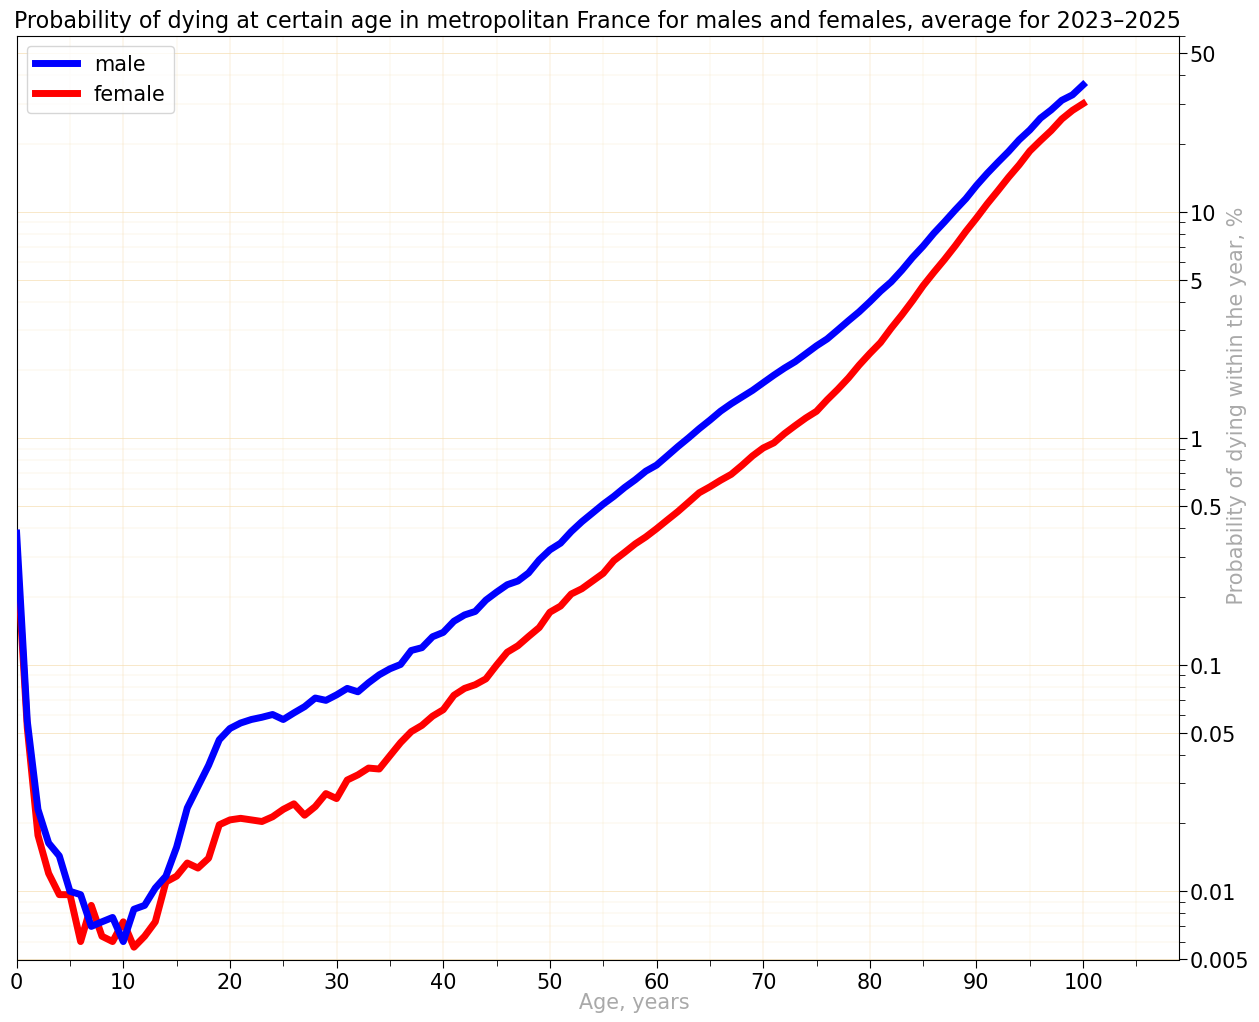

In [17]:
def create_chart_log(
        df, lang='en', dd_display='', ncol=1,
        plateau_years=plateau_years, show_plateau=False,
        age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
        title_en="Title of the chart", title_ru="Заголовок графика", title_fr="Titre du graphique",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()                 # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.005, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else title_fr if lang=='fr' else " " if lang=='nolang' else title_en,
              fontsize=15 if lang=='ru' else 16.25 if lang=='fr' else 16)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               "               Âge, années" if lang=='fr' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("                   Вероятность смерти в течение года, %" if lang=='ru' else
               "                         Probabilité de décès dans un an, %" if lang=='fr' else
               " " if lang=='nolang' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].fr_name if lang=='fr' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (21–30 years, including endpoints)
    print(f"  —— The zone of the 'plateau' ({plateau_years.start}–{plateau_years.stop} years, incl.) ——")

    plateau_mortality_male   = df.loc['male', plateau_years].mean()
    plateau_mortality_female = df.loc['female', plateau_years].mean()
    print(f"Average mortality rate at the plateau, %:  ♂: {plateau_mortality_male:.3f},  ♀: {plateau_mortality_female:.3f}")
    
    le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
    le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
    print("Life expectancy based on the average mortality rate at the plateau, years:  " +
          f"♂: {round(le_average_plateau_male, -1)},  ♀: {round(le_average_plateau_female, -1)}" +
          '\n')

    if show_plateau:  # show horizontal lines for the "plateaux"
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start, plateau_years.stop, color='lime', linewidth=2, alpha=0.5)

    # Calculate and show statistics about the zone of the Gompertz law of mortality (40–90 years)
    print(f"  —— The zone of the Gompertz law of mortality ({age_gompertz_start}–{age_gompertz_stop} age_gompertz_stop) ——")

    # Generate x-values for the considered interval
    x_gompertz = np.linspace(age_gompertz_start, age_gompertz_stop, age_gompertz_stop-age_gompertz_start+1)

    for group in ['male', 'female']:
        y_gompertz = df.loc[group, x_gompertz].values    # take the y values
        ln_y = np.log(y_gompertz)                        # take the logarithm of the y values
        b, ln_a = np.polyfit(x_gompertz, ln_y, deg=1)    # do linear regression
                                                         #    b - slope of the line
                                                         #    b - intersection of the 'ln a' with the y-axis
        a = np.exp(ln_a)                                 # recover the amplitude of the exponent
        print(f"Model for {group:>6}: y = {a:.6f} * exp({b:.6f} * x)")

        y_fit = a * np.exp(b * x_gompertz)               # approximated function

        ss_res = np.sum((y_gompertz - y_fit) ** 2)                # calculate the coefficient of determination
        ss_tot = np.sum((y_gompertz - np.mean(y_gompertz)) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f"Coefficient of determination (R²): {r2:.3f}")

        rate_perc, period_double = calculate_increase_rate_and_doubling_period(
            x_gompertz[0], x_gompertz[-1], y_fit[0], y_fit[-1])
        print(f"Annual increase: {rate_perc:6.3f} %,   doubling period: {period_double:6.3f} years")
        print()

        if show_gompertz:  # show sloped lines for the zone where Gompertz law is observed
            plt.plot(x_gompertz, y_fit, color='orange', linewidth=dd_display[group].width, alpha=0.5)
    
    plt.legend(loc='upper left', fontsize=15, ncol=ncol)
    
    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -fr' if lang=='fr' else ' -nolang' if lang=='nolang' else ''}.png",
                    bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


if (WHAT_TO_EXPLORE == 'single'):
    title_en=f"Probability of dying at certain age in metropolitan France in {SELECTED_YEAR} for males and females"
    title_ru=f"Вероятность смерти в определённом возрасте в метрополии Франции в {SELECTED_YEAR} для мужчин и женщин"
    title_fr=f"Probabilité de décès selon l’âge en France métropolitaine en {SELECTED_YEAR} chez les hommes et les femmes"
    file_name=f"Probability of Dying at Certain Age in France -log"
elif (WHAT_TO_EXPLORE == 'average_last_3'):
    title_en=f"Probability of dying at certain age in metropolitan France for males and females, average for {NAME_FOR_AVERAGE}"
    title_ru=f"Вероятность смерти в определённом возрасте в метрополии Франции для мужчин и женщин, {NAME_FOR_AVERAGE}"
    title_fr=f"Probabilité de décès selon l’âge en France métropolitaine chez les hommes et les femmes, {NAME_FOR_AVERAGE}"
    file_name=f"Probability of Dying at Certain Age in France 3 years average -log"
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")
    
for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
            title_en=title_en, title_ru=title_ru, title_fr=title_fr, file_name=file_name)

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.063,  ♀: 0.023
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 1590,  ♀: 4370

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.004048 * exp(0.087336 * x)
Coefficient of determination (R²): 0.971
Annual increase:  9.126 %,   doubling period:  7.937 years

Model for female: y = 0.001422 * exp(0.093915 * x)
Coefficient of determination (R²): 0.929
Annual increase:  9.847 %,   doubling period:  7.381 years



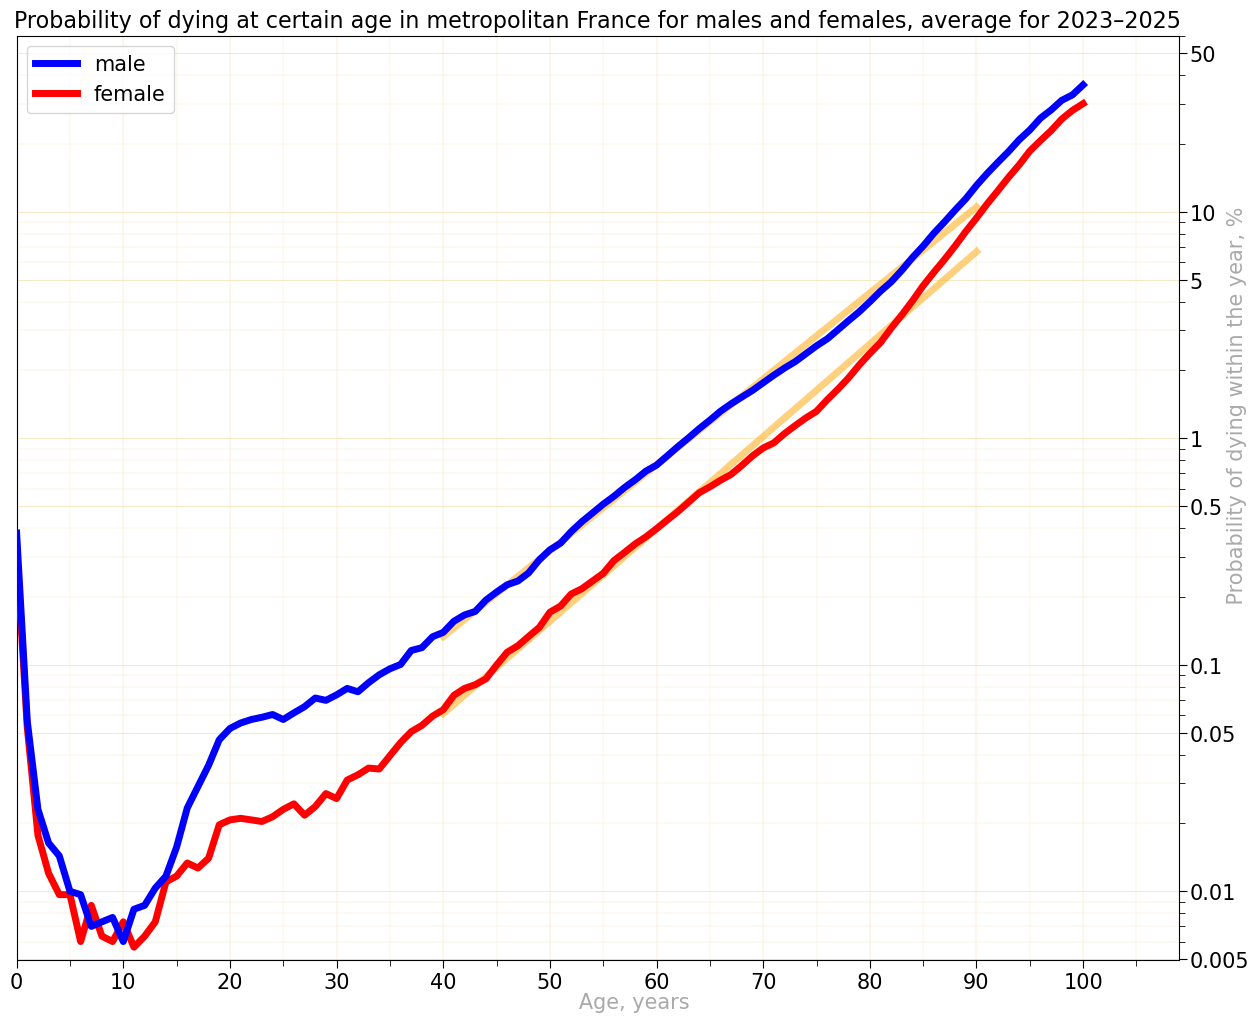

In [18]:
if (WHAT_TO_EXPLORE == 'single'):
    file_name=f"Probability of Dying at Certain Age in France -gompertz"
elif (WHAT_TO_EXPLORE == 'average_last_3'):
    file_name=f"Probability of Dying at Certain Age in France 3 years average -gompertz"
else:
     raise ValueError(f"Variable WHAT_TO_EXPLORE has an invalid value: '{WHAT_TO_EXPLORE}'")
    
for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
            title_en=title_en, title_ru=title_ru, title_fr=title_fr, file_name=file_name)

<br>
<br>

In [20]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)